# Emotional Text Classification: Standard NN vs Dynamic NN

This notebook compares a **Standard Neural Network** with a **Dynamic Neural Network** for emotional text classification.

## Key Features
- **Standard NN**: Fixed architecture with scheduled learning rate decay
- **Dynamic NN**: Adaptive architecture with reward/penalty system for learning rate

## Emotions Classified
1. Happy
2. Sad
3. Angry
4. Fearful
5. Surprised
6. Disgusted
7. Neutral

## Table of Contents
1. [Setup](#1-setup)
2. [Data Generation](#2-data)
3. [Data Exploration](#3-explore)
4. [Feature Extraction](#4-features)
5. [Standard NN Training](#5-standard)
6. [Dynamic NN Training](#6-dynamic)
7. [Comparison](#7-comparison)
8. [Emotional State Analysis](#8-emotional)
9. [Conclusions](#9-conclusions)

## 1. Setup <a id='1-setup'></a>

In [25]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add parent directory to path for imports
notebook_dir = Path(os.getcwd()).parent if 'data' in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(notebook_dir))

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"NumPy version: {np.__version__}")
print(f"Working directory: {os.getcwd()}")

NumPy version: 2.4.0
Working directory: c:\Workspaces\dynamic_nn\notebooks\emotional_classifier\data


In [26]:
# Import our modules
import importlib
import src.emotional_data_generator
import src.text_vectorizer
import src.standard_nn
import src.dynamic_nn
import src.comparison

# Reload all modules to ensure latest code
importlib.reload(src.emotional_data_generator)
importlib.reload(src.text_vectorizer)
importlib.reload(src.standard_nn)
importlib.reload(src.dynamic_nn)
importlib.reload(src.comparison)

from src.emotional_data_generator import EmotionalDataGenerator, Emotion
from src.text_vectorizer import TextVectorizer, VectorizerConfig, create_vectorizer
from src.standard_nn import StandardNeuralNetwork, StandardNNConfig
from src.dynamic_nn import DynamicNeuralNetwork, DynamicNNConfig
from src.comparison import EmotionalClassifierComparison

print("All modules imported and reloaded successfully!")

All modules imported and reloaded successfully!


## 2. Data Generation <a id='2-data'></a>

Generate synthetic emotional text data with:
- 7 emotion categories
- Variable intensity levels
- Bilingual support (English/Arabic)

In [27]:
# Generate dataset
NUM_SAMPLES = 1000

generator = EmotionalDataGenerator(seed=SEED)
samples = generator.generate_samples(
    num_samples=NUM_SAMPLES,
    language_ratio=0.7,  # 70% English, 30% Arabic
    balanced=True
)

# Get statistics
stats = generator.get_statistics()
print(f"\nDataset Statistics:")
print(f"  Total samples: {stats['total_samples']}")
print(f"  Number of classes: {stats['num_classes']}")
print(f"  Avg intensity: {stats['avg_intensity']:.2f}")


Dataset Statistics:
  Total samples: 1000
  Number of classes: 7
  Avg intensity: 0.50


In [28]:
# Split into train/val/test
train_samples, val_samples, test_samples = generator.split_data(
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)

print(f"Train: {len(train_samples)} samples")
print(f"Val:   {len(val_samples)} samples")
print(f"Test:  {len(test_samples)} samples")

Train: 800 samples
Val:   100 samples
Test:  100 samples


## 3. Data Exploration <a id='3-explore'></a>

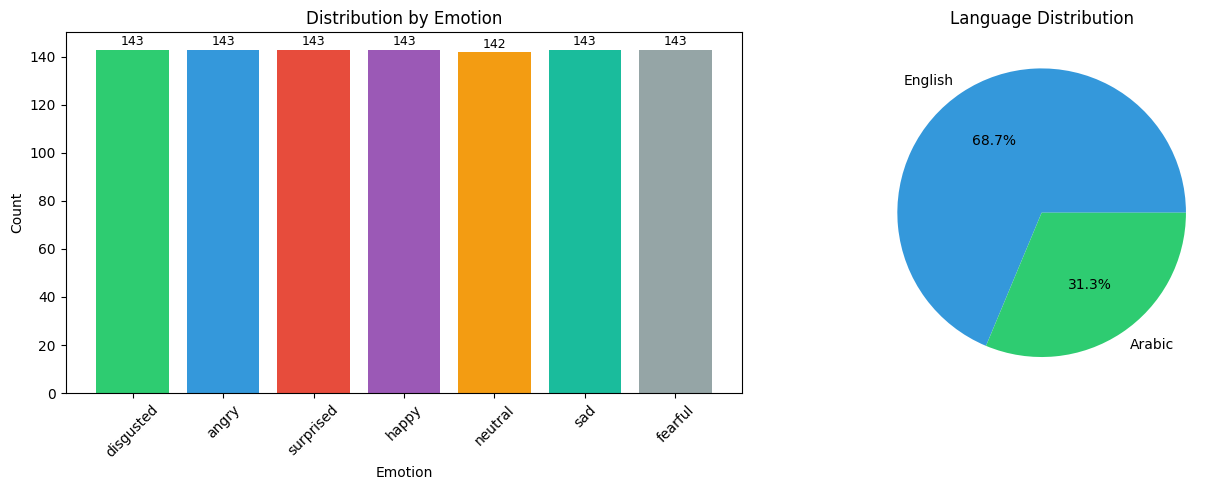

In [29]:
# Emotion distribution
emotion_counts = stats['emotion_distribution']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Emotion distribution
ax1 = axes[0]
emotions = list(emotion_counts.keys())
counts = list(emotion_counts.values())
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#95a5a6']
bars = ax1.bar(emotions, counts, color=colors)
ax1.set_xlabel('Emotion')
ax1.set_ylabel('Count')
ax1.set_title('Distribution by Emotion')
ax1.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    ax1.annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Language distribution
ax2 = axes[1]
lang_counts = stats['language_distribution']
ax2.pie(lang_counts.values(), labels=['English', 'Arabic'], autopct='%1.1f%%',
        colors=['#3498db', '#2ecc71'])
ax2.set_title('Language Distribution')

plt.tight_layout()
plt.show()

In [30]:
# Show sample texts by emotion
print("Sample Texts by Emotion:")
print("=" * 70)

for emotion in Emotion:
    emotion_samples = [s for s in samples if s.emotion == emotion][:2]
    print(f"\n{emotion.value.upper()}:")
    for sample in emotion_samples:
        print(f"  [{sample.language}] {sample.text}")

Sample Texts by Emotion:

HAPPY:
  [ar] لا أستطيع التوقف عن الابتسام!
  [ar] لا أستطيع التوقف عن الابتسام!

SAD:
  [en] I'm fairly disappointed with how things turned out.
  [en] I feel pretty lost and alone.

ANGRY:
  [en] I can't believe how fairly unfair this is!
  [ar] أشعر بالخيانة والغضب!

FEARFUL:
  [en] This situation is incredibly frightening.
  [en] I feel absolutely worried about the future.

SURPRISED:
  [ar] هذا فاجأني إلى حد ما!
  [en] I never expected this, I'm slightly bewildered!

DISGUSTED:
  [en] This makes me feel a bit sick.
  [en] I'm quite appalled by what I see.

NEUTRAL:
  [en] It is what it is.
  [ar] لا يحدث شيء كثير اليوم.


## 4. Feature Extraction <a id='4-features'></a>

Convert text to numerical features using TF-IDF with character n-grams.

In [31]:
# Create vectorizer
train_texts = [s.text for s in train_samples]

vectorizer = create_vectorizer(
    train_texts,
    max_features=500,
    use_tfidf=True,
    use_ngrams=True
)

# Get vectorizer summary
summary = vectorizer.get_summary()
print("Vectorizer Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

Vectorizer Summary:
  vocab_size: 368
  ngram_vocab_size: 132
  total_features: 500
  use_tfidf: True
  use_ngrams: True
  fitted: True


In [32]:
# Vectorize all data
X_train = vectorizer.transform([s.text for s in train_samples])
X_val = vectorizer.transform([s.text for s in val_samples])
X_test = vectorizer.transform([s.text for s in test_samples])

y_train = np.array([s.label for s in train_samples])
y_val = np.array([s.label for s in val_samples])
y_test = np.array([s.label for s in test_samples])

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Number of classes: {len(set(y_train))}")
print(f"Class distribution: {np.bincount(y_train)}")

X_train shape: (800, 500)
y_train shape: (800,)
Number of classes: 7
Class distribution: [110 119 117 112 111 118 113]


## 5. Standard Neural Network Training <a id='5-standard'></a>

Train a standard feedforward neural network with:
- Fixed architecture
- Scheduled learning rate decay

In [33]:
# Configure standard NN
std_config = StandardNNConfig(
    input_size=vectorizer.n_features,
    hidden_sizes=[256, 128, 64],
    output_size=7,  # 7 emotions
    dropout=0.2,
    activation='relu',
    seed=SEED
)

print("Standard NN Configuration:")
print(f"  Input size: {std_config.input_size}")
print(f"  Hidden sizes: {std_config.hidden_sizes}")
print(f"  Output size: {std_config.output_size}")
print(f"  Dropout: {std_config.dropout}")

Standard NN Configuration:
  Input size: 500
  Hidden sizes: [256, 128, 64]
  Output size: 7
  Dropout: 0.2


In [34]:
# Create and train standard NN
standard_model = StandardNeuralNetwork(std_config)
print(f"Total parameters: {standard_model.count_parameters():,}")

# Train
std_history = standard_model.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=100,
    batch_size=32,
    learning_rate=0.01,
    lr_decay=0.95,
    lr_decay_epochs=20,
    early_stopping_patience=20,
    verbose=True
)

Total parameters: 169,863
STANDARD NEURAL NETWORK TRAINING
Architecture: 500 -> [256, 128, 64] -> 7
Parameters: 169,863
Training samples: 800
Epoch 0: cost=1.9482, acc=18.88%, lr=0.010000, val_cost=1.9376, val_acc=19.00%
Epoch 10: cost=1.2656, acc=90.25%, lr=0.010000, val_cost=1.1129, val_acc=84.00%
Epoch 20: cost=0.1181, acc=99.75%, lr=0.009500, val_cost=0.0558, val_acc=100.00%
Epoch 30: cost=0.0402, acc=99.88%, lr=0.009500, val_cost=0.0097, val_acc=100.00%
Epoch 40: cost=0.0207, acc=100.00%, lr=0.009025, val_cost=0.0034, val_acc=100.00%
Epoch 50: cost=0.0162, acc=100.00%, lr=0.009025, val_cost=0.0022, val_acc=100.00%
Epoch 60: cost=0.0125, acc=100.00%, lr=0.008574, val_cost=0.0017, val_acc=100.00%
Epoch 70: cost=0.0108, acc=100.00%, lr=0.008574, val_cost=0.0008, val_acc=100.00%
Epoch 80: cost=0.0081, acc=100.00%, lr=0.008145, val_cost=0.0010, val_acc=100.00%
Epoch 90: cost=0.0049, acc=100.00%, lr=0.008145, val_cost=0.0005, val_acc=100.00%
Training completed in 4.94s
Best cost: 0.0003

In [35]:
# Evaluate standard NN
std_eval = standard_model.evaluate(X_test, y_test)
print("\nStandard NN - Test Results:")
print(f"  Accuracy: {std_eval['accuracy']:.2%}")
print(f"  Top-3 Accuracy: {std_eval['top3_accuracy']:.2%}")
print(f"  Loss: {std_eval['loss']:.4f}")


Standard NN - Test Results:
  Accuracy: 100.00%
  Top-3 Accuracy: 100.00%
  Loss: 0.0057


## 6. Dynamic Neural Network Training <a id='6-dynamic'></a>

Train a Dynamic Neural Network with:
- Adaptive architecture (add/remove nodes and layers)
- 3-phase training (Exploration, Estimation, Main Training)
- **Reward/Penalty System** for learning rate adaptation
- Health monitoring (cancer/alzheimer scores)
- Depression/Excitement ratio tracking

In [36]:
# Configure dynamic NN
dyn_config = DynamicNNConfig(
    input_size=vectorizer.n_features,
    initial_hidden_sizes=[128, 64],
    output_size=7,
    min_nodes=16,
    max_nodes=512,
    min_layers=1,
    max_layers=8,
    dropout=0.2,
    activation='relu',
    seed=SEED
)

print("Dynamic NN Configuration:")
print(f"  Input size: {dyn_config.input_size}")
print(f"  Initial hidden: {dyn_config.initial_hidden_sizes}")
print(f"  Node range: {dyn_config.min_nodes}-{dyn_config.max_nodes}")
print(f"  Layer range: {dyn_config.min_layers}-{dyn_config.max_layers}")

Dynamic NN Configuration:
  Input size: 500
  Initial hidden: [128, 64]
  Node range: 16-512
  Layer range: 1-8


In [37]:
# Create and train dynamic NN
dynamic_model = DynamicNeuralNetwork(dyn_config)
print(f"Initial parameters: {dynamic_model.count_parameters():,}")

# Train with 3-phase approach and reward/penalty system
dyn_history = dynamic_model.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    batch_size=32,
    learning_rate=0.01,
    verbose=True
)

Initial parameters: 72,839
DYNAMIC NEURAL NETWORK TRAINING
Initial architecture: [(500, 128), (128, 64), (64, 7)]
Initial parameters: 72,839
Training samples: 800

PHASE 1: EXPLORATION (10 epochs)
  Epoch 0: cost=1.9456, acc=20.50%
  Epoch 1: cost=1.9293, acc=28.12%
  Epoch 2: cost=1.9118, acc=38.00%
  Epoch 3: cost=1.8943, acc=42.75%
  Epoch 4: cost=1.8757, acc=55.62%
  Epoch 5: cost=1.8478, acc=58.38%
  Epoch 6: cost=1.8065, acc=64.62%
  Epoch 7: cost=1.7696, acc=68.25%
  Epoch 8: cost=1.7260, acc=78.12%
  Epoch 9: cost=1.6475, acc=77.12%

PHASE 2: ESTIMATION
  Estimated epochs for convergence: 55

PHASE 3: MAIN TRAINING (55 epochs)
  Using Reward/Penalty System for adaptive LR
  Epoch 0: cost=1.5734, acc=81.88%, eff=100.00%, lr=0.010000, R/P=1/0, val_acc=77.00%
  Epoch 10: cost=0.4732, acc=98.38%, eff=100.00%, lr=0.010000, R/P=11/0, val_acc=94.00%
  Epoch 20: cost=0.1282, acc=99.75%, eff=100.00%, lr=0.010000, R/P=21/0, val_acc=100.00%
  Epoch 30: cost=0.0615, acc=100.00%, eff=100.00

In [38]:
# Evaluate dynamic NN
dyn_eval = dynamic_model.evaluate(X_test, y_test)
print("\nDynamic NN - Test Results:")
print(f"  Accuracy: {dyn_eval['accuracy']:.2%}")
print(f"  Top-3 Accuracy: {dyn_eval['top3_accuracy']:.2%}")
print(f"  Loss: {dyn_eval['loss']:.4f}")

# Health status
health = dynamic_model.health_status()
print(f"\nHealth Status: {health['state']}")
print(f"  Cancer Score: {health['cancer_score']:.2%}")
print(f"  Alzheimer Score: {health['alzheimer_score']:.2%}")

# Emotional state
print(f"\nEmotional State: {health['emotional_state']}")
print(f"  Depression Ratio: {health['depression_ratio']:.2%}")
print(f"  Excitement Ratio: {health['excitement_ratio']:.2%}")
print(f"  Total Rewards: {health['total_rewards']}")
print(f"  Total Penalties: {health['total_penalties']}")
print(f"  LR Resets: {health['lr_reset_count']}")


Dynamic NN - Test Results:
  Accuracy: 99.00%
  Top-3 Accuracy: 100.00%
  Loss: 0.0220

Health Status: Healthy
  Cancer Score: 0.00%
  Alzheimer Score: 3.64%

Emotional State: excited
  Depression Ratio: 20.37%
  Excitement Ratio: 79.63%
  Total Rewards: 43
  Total Penalties: 11
  LR Resets: 53


## 7. Model Comparison <a id='7-comparison'></a>

Compare Standard NN vs Dynamic NN on:
- Accuracy metrics
- Parameter efficiency
- Training dynamics
- Per-class performance

In [39]:
# Create comparison evaluator
evaluator = EmotionalClassifierComparison(
    standard_model=standard_model,
    dynamic_model=dynamic_model,
    vectorizer=vectorizer
)

# Run full comparison
metrics = evaluator.evaluate(X_test, y_test, verbose=True)


EMOTIONAL CLASSIFIER COMPARISON: Standard NN vs Dynamic NN

--- ACCURACY ---
Model           Accuracy     Top-3        Loss        
---------------------------------------------------
Standard NN        100.00%    100.00%     0.0057
Dynamic NN          99.00%    100.00%     0.0220
Difference          -1.00%

--- PARAMETERS ---
Standard NN: 169,863 parameters
Dynamic NN:  69,523 parameters
Difference:  -100,340 (-59.1%)

--- TRAINING TIME ---
Standard NN: 4.94s
Dynamic NN:  1.62s
Difference:  -3.31s

--- DYNAMIC NN HEALTH ---
Cancer Score:     0.00%
Alzheimer Score:  3.64%
Depression Ratio: 20.37%
Excitement Ratio: 79.63%
Emotional State:  excited

--- PER-CLASS ACCURACY ---
Emotion      Standard     Dynamic      Winner      
------------------------------------------------
happy           100.00%    100.00% Tie         
sad             100.00%    100.00% Tie         
angry           100.00%    100.00% Tie         
fearful         100.00%    100.00% Tie         
surprised       100.00%

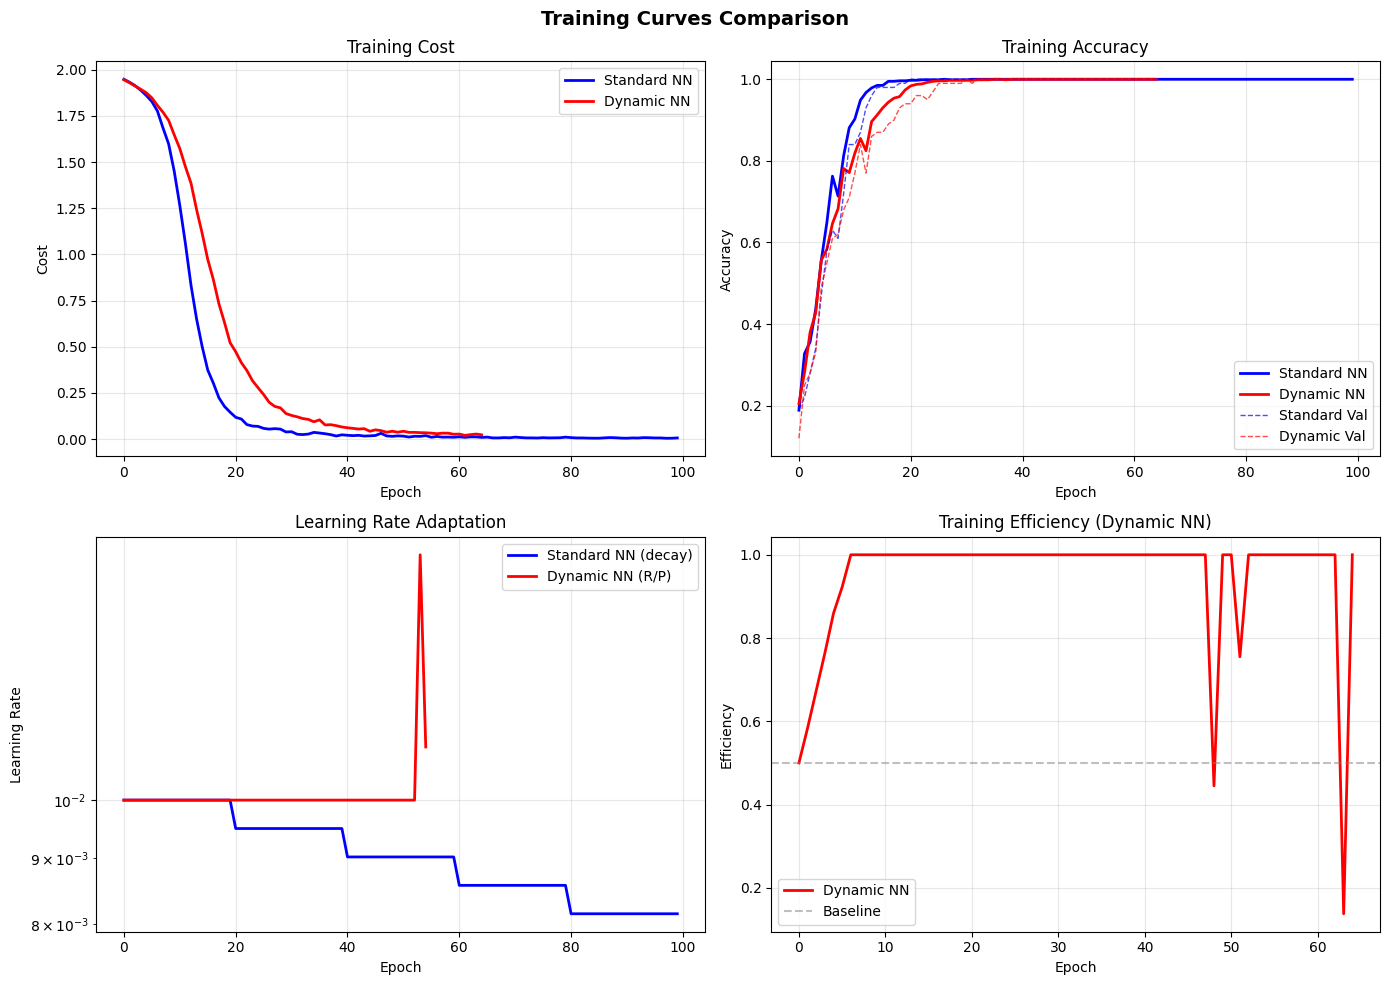

In [40]:
# Plot training curves
evaluator.plot_training_curves()

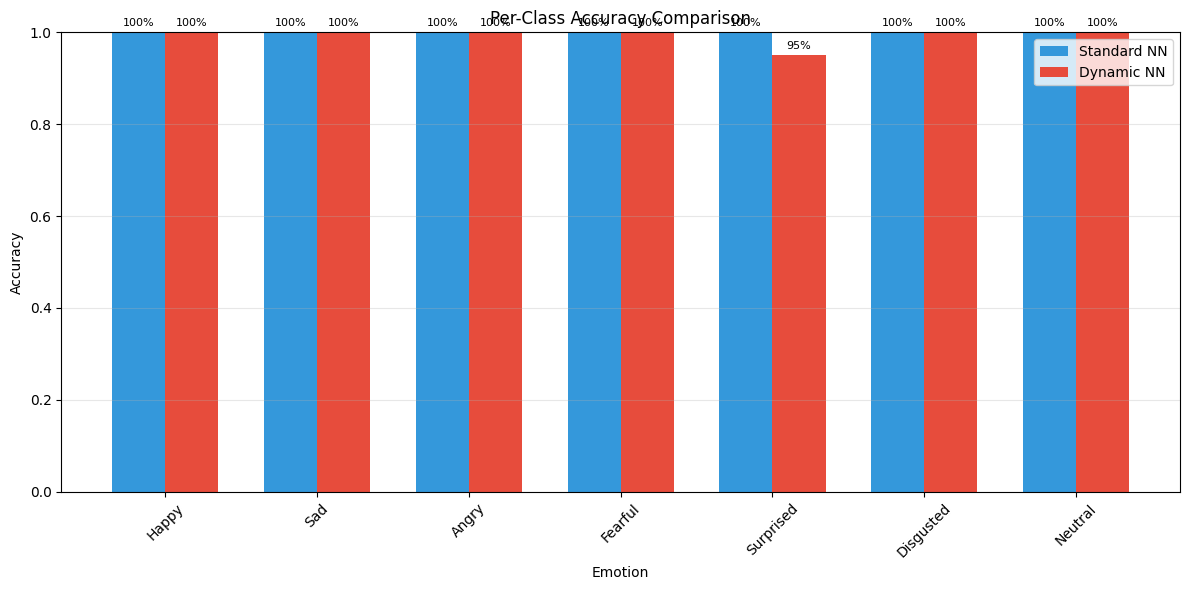

In [41]:
# Plot per-class accuracy
evaluator.plot_per_class_accuracy()

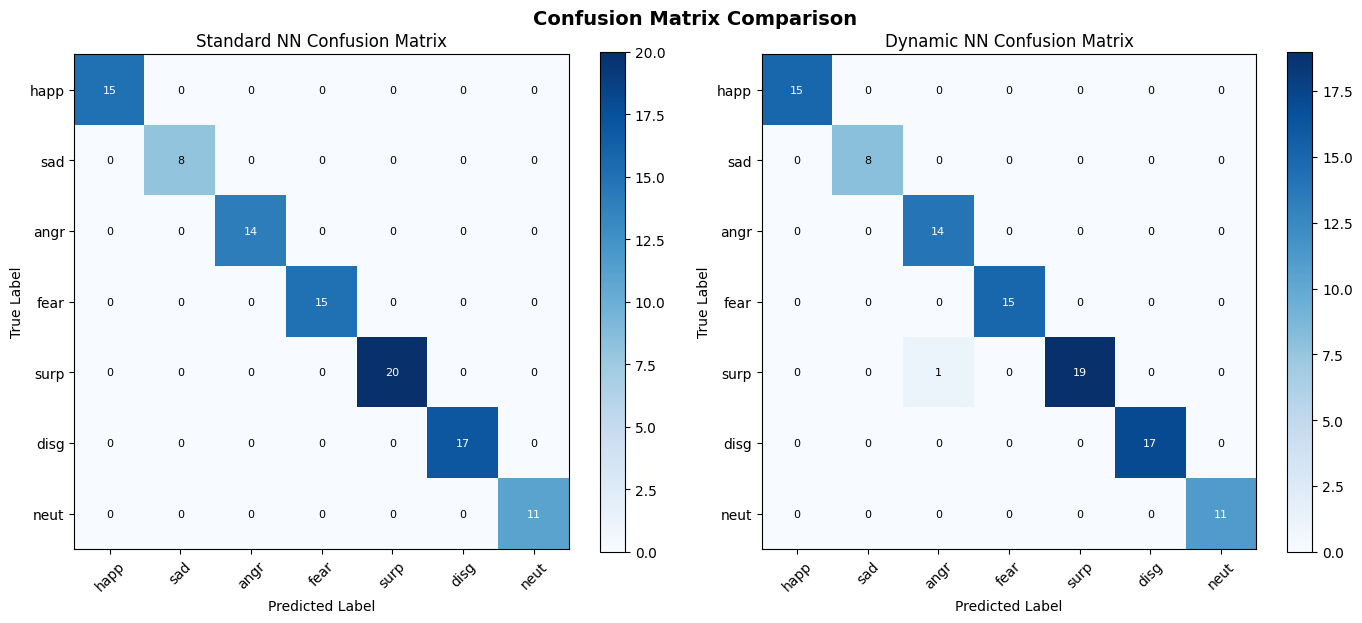

In [42]:
# Plot confusion matrices
evaluator.plot_confusion_comparison(X_test, y_test)

## 8. Emotional State Analysis <a id='8-emotional'></a>

Analyze the Dynamic NN's emotional state during training:
- Depression ratio (penalties / total adjustments)
- Excitement ratio (rewards / total adjustments)
- Learning rate adaptation
- Health scores

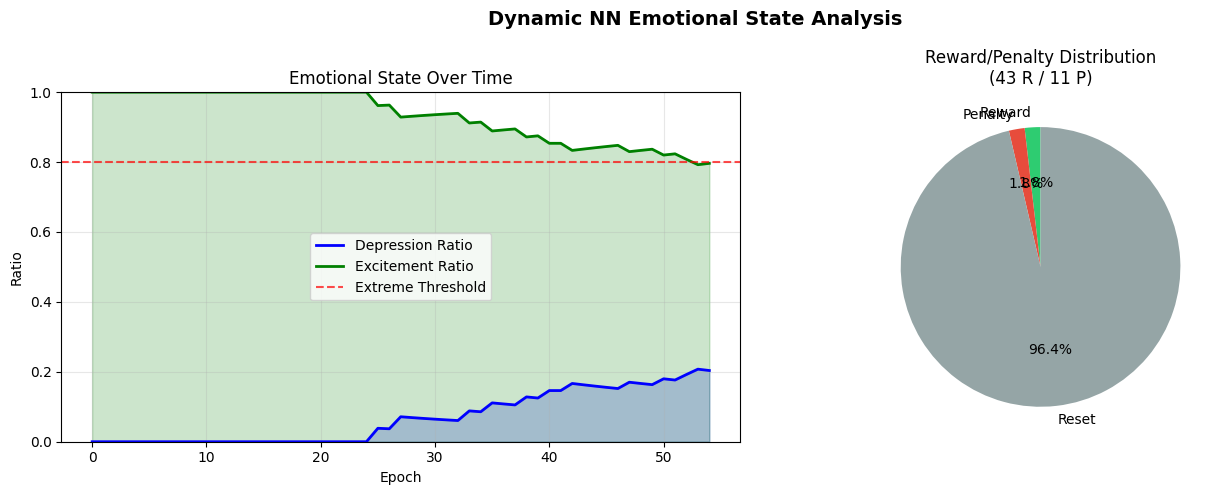

In [43]:
# Plot emotional state
evaluator.plot_emotional_state()

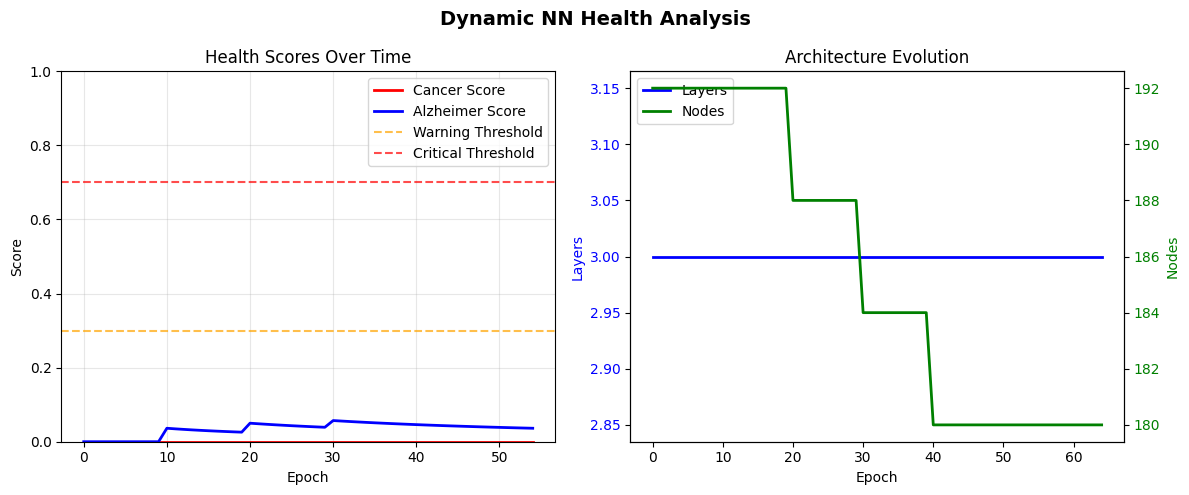

In [44]:
# Plot health scores
evaluator.plot_health_scores()

In [45]:
# Architecture changes summary
arch = dynamic_model.get_architecture_summary()
print("\nDynamic NN Architecture Evolution:")
print(f"  Final layer sizes: {arch['layer_sizes']}")
print(f"  Total nodes: {arch['total_nodes']}")
print(f"  Total parameters: {arch['total_parameters']:,}")
print(f"\nArchitecture Changes:")
print(f"  Layers: +{arch['layers_added']} / -{arch['layers_removed']}")
print(f"  Nodes: +{arch['nodes_added']} / -{arch['nodes_removed']}")

# Reward/Penalty summary
print("\nReward/Penalty System Summary:")
print(f"  Total Rewards: {dyn_history.total_rewards} (LR decreased when training improved)")
print(f"  Total Penalties: {dyn_history.total_penalties} (LR increased when training degraded)")
print(f"  LR Resets: {dyn_history.lr_reset_count} (reset to baseline on extreme states)")

if dyn_history.total_rewards + dyn_history.total_penalties > 0:
    total = dyn_history.total_rewards + dyn_history.total_penalties
    depression = dyn_history.total_penalties / total
    excitement = dyn_history.total_rewards / total
    print(f"  Depression Ratio: {depression:.2%}")
    print(f"  Excitement Ratio: {excitement:.2%}")
    
    if depression > 0.8:
        emotional_health = "UNHEALTHY (Extreme Depression)"
    elif excitement > 0.8:
        emotional_health = "UNHEALTHY (Extreme Excitement)"
    elif 0.3 <= depression <= 0.7:
        emotional_health = "HEALTHY (Balanced)"
    else:
        emotional_health = "MODERATE"
    print(f"  Emotional Health: {emotional_health}")


Dynamic NN Architecture Evolution:
  Final layer sizes: [(500, 124), (124, 56), (56, 7)]
  Total nodes: 180
  Total parameters: 69,523

Architecture Changes:
  Layers: +0 / -0
  Nodes: +0 / -12

Reward/Penalty System Summary:
  Total Rewards: 43 (LR decreased when training improved)
  Total Penalties: 11 (LR increased when training degraded)
  LR Resets: 53 (reset to baseline on extreme states)
  Depression Ratio: 20.37%
  Excitement Ratio: 79.63%
  Emotional Health: MODERATE


## 9. Conclusions <a id='9-conclusions'></a>

In [46]:
# Generate comparison report
report = evaluator.generate_report()
print(report)

EMOTIONAL CLASSIFIER COMPARISON REPORT
Standard Neural Network vs Dynamic Neural Network

## Summary
- Standard NN Accuracy: 100.00%
- Dynamic NN Accuracy: 99.00%
- Accuracy Difference: -1.00%

## Parameters
- Standard NN: 169,863
- Dynamic NN: 69,523
- Difference: -100,340 (-59.1%)

## Training Time
- Standard NN: 4.94s
- Dynamic NN: 1.62s

## Dynamic NN Health Status
- Cancer Score: 0.00%
- Alzheimer Score: 3.64%
- Depression Ratio: 20.37%
- Excitement Ratio: 79.63%
- Emotional State: excited

## Conclusion
Models have similar accuracy, but Dynamic NN is more parameter-efficient.



In [47]:
# Final summary
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

acc_diff = metrics.accuracy_diff
param_diff = metrics.parameter_diff

print(f"\nAccuracy: Dynamic NN {'outperforms' if acc_diff > 0 else 'underperforms'} Standard NN by {abs(acc_diff):.2%}")
print(f"Parameters: Dynamic NN uses {abs(param_diff):,} {'more' if param_diff > 0 else 'fewer'} parameters")

print("\nKey Insights:")
print(f"  1. Standard NN: Fixed LR decay (scheduled)")
print(f"  2. Dynamic NN: Adaptive LR via reward/penalty system")
print(f"  3. Dynamic NN emotional health: {health['emotional_state']}")

if acc_diff > 0.02 and param_diff < 0:
    print("\nConclusion: Dynamic NN WINS - better accuracy with fewer parameters!")
    print("The reward/penalty system effectively adapts learning rate to training dynamics.")
elif acc_diff > 0.02:
    print("\nConclusion: Dynamic NN achieves better accuracy but uses more parameters.")
elif param_diff < 0:
    print("\nConclusion: Dynamic NN uses fewer parameters but with slightly lower accuracy.")
else:
    print("\nConclusion: Both models perform similarly on this task.")

print("\n" + "=" * 70)


FINAL SUMMARY

Accuracy: Dynamic NN underperforms Standard NN by 1.00%
Parameters: Dynamic NN uses 100,340 fewer parameters

Key Insights:
  1. Standard NN: Fixed LR decay (scheduled)
  2. Dynamic NN: Adaptive LR via reward/penalty system
  3. Dynamic NN emotional health: excited

Conclusion: Dynamic NN uses fewer parameters but with slightly lower accuracy.



In [48]:
# Save models
import os
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

standard_model.save(f'{models_dir}/standard_nn.npz')
dynamic_model.save(f'{models_dir}/dynamic_nn.npz')
vectorizer.save(f'{models_dir}/vectorizer.json')

print(f"Models saved to {models_dir}/")

Models saved to ../models/
